# Practical Exercise 2 - Task 1
# Vanilla GAN on MNIST using PyTorch

In this notebook, we implement a simple Vanilla GAN to generate MNIST-like digit images.

We will:
1. Load the MNIST dataset
2. Build the Generator and Discriminator
3. Train the GAN
4. Visualize generated samples

In [1]:
# Standard library imports
import os
import random
from pathlib import Path

# Numerical and plotting imports
import numpy as np
import matplotlib.pyplot as plt

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Weights & Biases
import wandb

## General setup

In [2]:
# General experiment setup

LOG_WANDB = True
SEED = 1

# Paths
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR
WANDB_DIR = PROJECT_DIR
OUT_DIR = PROJECT_DIR / "out"

OUT_DIR.mkdir(parents=True, exist_ok=True)

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Data loading settings
PIN_MEMORY = True if torch.cuda.is_available() else False
NUM_WORKERS = 4


# CPU optimization
torch.set_num_threads(8)
torch.set_num_interop_threads(8)

Using device: cpu


## Configuration

In [3]:
# Training configuration
config = {
    "batch_size": 64,
    "latent_dim": 100,
    "g_hidden_dim": 128,
    "d_hidden_dim": 128,
    "image_dim": 28 * 28,
    "g_lr": 1e-4,
    "d_lr": 1e-4
    "epochs": 100,
    "jupyter_plot_interval": 10,
    "wandb_image_interval": 1,
    "optimizer": "Adam",
    "betas": (0.9, 0.999),
    "dataset": "MNIST",
    "model": "Vanilla GAN",
    "seed": SEED
}

# config

## Initialize Weights & Biases

In [4]:
# Shared W&B settings
WANDB_ENTITY = "d7047e-group12"
WANDB_PROJECT = "Lab2"

wandb_kwargs = dict(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    name="Task1 - Vanilla GAN MNIST",
    tags=["Task 1", "GAN", "MNIST", "Vanilla GAN"],
    dir=str(WANDB_DIR),
    config=config,
    mode="online" if LOG_WANDB else "disabled",
)

wandb.login()
wandb.init(**wandb_kwargs)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\hamsab\_netrc.
wandb: Currently logged in as: hamid-sabeti (d7047e-group12) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Load MNIST dataset

In [5]:
# Transform pipeline for MNIST
# ToTensor converts images to tensors in the range [0, 1]
transform = transforms.Compose([
    transforms.ToTensor()
])

# Download and load the training set
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

# DataLoader handles batching and shuffling
train_loader = DataLoader(
    train_dataset,
    batch_size=config["batch_size"],
    shuffle=True,
    drop_last=True
)

print("Number of training samples:", len(train_dataset))
print("Number of batches per epoch:", len(train_loader))

Number of training samples: 60000
Number of batches per epoch: 937


## Visualize a few real images

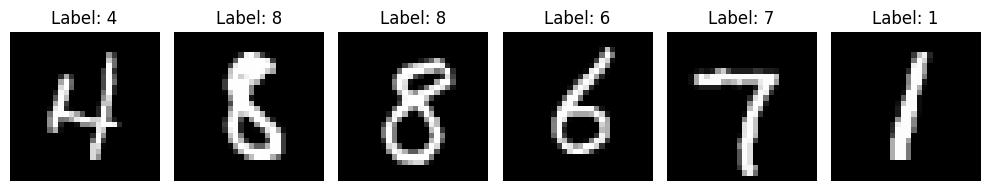

In [6]:
# Get one batch of real images
real_images, real_labels = next(iter(train_loader))

# Plot a few images from the batch
fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for i in range(6):
    axes[i].imshow(real_images[i].squeeze(), cmap="gray")
    axes[i].set_title(f"Label: {real_labels[i].item()}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Define the Generator network

In [7]:
# Generator network
# Input: latent noise vector
# Output: generated image vector of size 784

class Generator(nn.Module):
    def __init__(self, latent_dim, hidden_dim, image_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, image_dim),
            nn.Sigmoid()
        )

    def forward(self, z):
        return self.model(z)

## Define the Discriminator network

In [8]:
# Discriminator network
# Input: flattened image vector
# Output: probability that the image is real

class Discriminator(nn.Module):
    def __init__(self, image_dim, hidden_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(image_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

## Initialize models

In [9]:
# Create model instances and move them to device
G = Generator(
    latent_dim=config["latent_dim"],
    hidden_dim=config["g_hidden_dim"],
    image_dim=config["image_dim"]
).to(device)

D = Discriminator(
    image_dim=config["image_dim"],
    hidden_dim=config["d_hidden_dim"]
).to(device)

print(G)
print()
print(D)

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=784, bias=True)
    (3): Sigmoid()
  )
)

Discriminator(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1, bias=True)
    (3): Sigmoid()
  )
)


## Define the loss function and optimizers

In [10]:
# Binary cross entropy loss for Vanilla GAN
criterion = nn.BCELoss()

# Separate optimizers for Generator and Discriminator
g_optimizer = optim.Adam(
    G.parameters(),
    lr=config["g_lr"],
    betas=config["betas"]
)

d_optimizer = optim.Adam(
    D.parameters(),
    lr=config["d_lr"],
    betas=config["betas"]
)

## Helper function to visualize generated images

In [11]:
# Display generated images inside the notebook
def show_generated_images(generator, latent_dim, num_images=16):
    generator.eval()

    with torch.no_grad():
        z = torch.randn(num_images, latent_dim, device=device)
        fake_images = generator(z).view(-1, 28, 28).cpu().numpy()

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(fake_images[i], cmap="gray")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    generator.train()

## Helper function for W&B image logging

In [12]:
# Create a matplotlib figure for W&B image logging
def make_generated_figure(generator, latent_dim, num_images=16):
    generator.eval()

    with torch.no_grad():
        z = torch.randn(num_images, latent_dim, device=device)
        fake_images = generator(z).view(-1, 28, 28).cpu().numpy()

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(fake_images[i], cmap="gray")
        ax.axis("off")

    plt.tight_layout()
    generator.train()
    return fig

## Train the Vanilla GAN

Epoch [1/100] | D_loss: 0.1407 | G_loss: 5.4023
Epoch [2/100] | D_loss: 0.1027 | G_loss: 4.2340
Epoch [3/100] | D_loss: 0.1506 | G_loss: 4.1790
Epoch [4/100] | D_loss: 0.2816 | G_loss: 4.1571
Epoch [5/100] | D_loss: 0.4161 | G_loss: 3.6764
Epoch [6/100] | D_loss: 0.6010 | G_loss: 3.3475
Epoch [7/100] | D_loss: 0.7492 | G_loss: 3.0039
Epoch [8/100] | D_loss: 0.7810 | G_loss: 2.5929
Epoch [9/100] | D_loss: 0.7575 | G_loss: 2.7545
Epoch [10/100] | D_loss: 0.7670 | G_loss: 2.4553


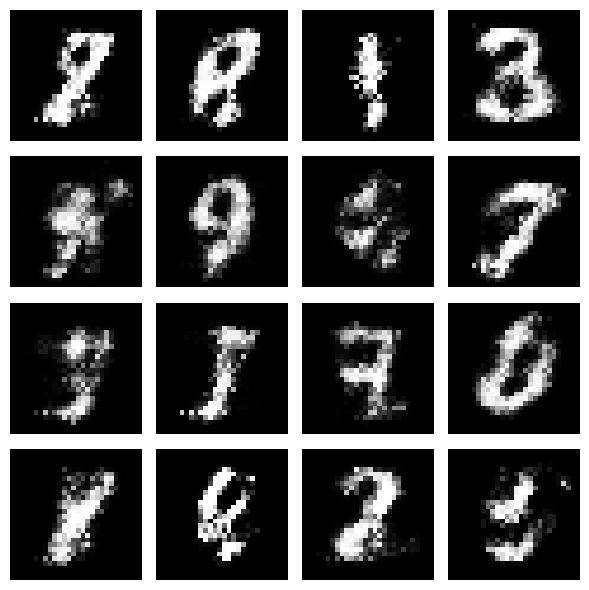

Epoch [11/100] | D_loss: 0.8009 | G_loss: 2.4412
Epoch [12/100] | D_loss: 0.8530 | G_loss: 2.2852
Epoch [13/100] | D_loss: 0.8699 | G_loss: 2.1627
Epoch [14/100] | D_loss: 0.8818 | G_loss: 2.0419
Epoch [15/100] | D_loss: 0.9031 | G_loss: 1.9735
Epoch [16/100] | D_loss: 0.9086 | G_loss: 1.8914
Epoch [17/100] | D_loss: 0.9073 | G_loss: 1.8276
Epoch [18/100] | D_loss: 0.9343 | G_loss: 1.7596
Epoch [19/100] | D_loss: 0.9298 | G_loss: 1.7030
Epoch [20/100] | D_loss: 0.9430 | G_loss: 1.6875


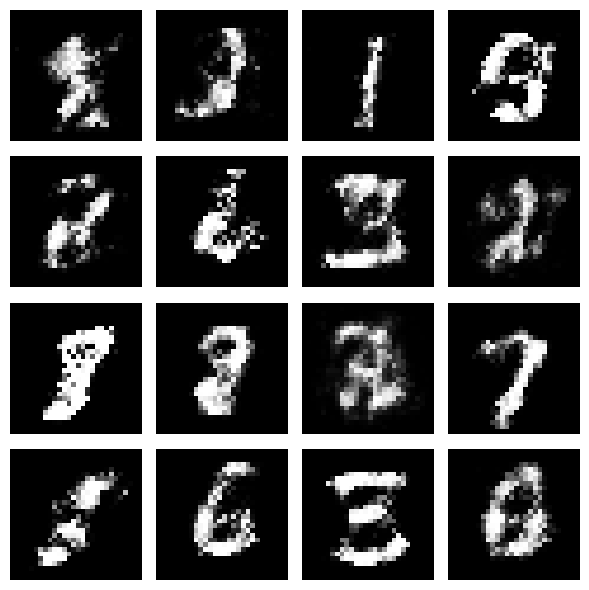

Epoch [21/100] | D_loss: 0.9280 | G_loss: 1.7319
Epoch [22/100] | D_loss: 0.9338 | G_loss: 1.6761
Epoch [23/100] | D_loss: 0.9339 | G_loss: 1.6148
Epoch [24/100] | D_loss: 0.9361 | G_loss: 1.6324
Epoch [25/100] | D_loss: 0.9436 | G_loss: 1.5597
Epoch [26/100] | D_loss: 0.9401 | G_loss: 1.6154
Epoch [27/100] | D_loss: 0.9312 | G_loss: 1.5813
Epoch [28/100] | D_loss: 0.9252 | G_loss: 1.5762
Epoch [29/100] | D_loss: 0.9279 | G_loss: 1.6222
Epoch [30/100] | D_loss: 0.9172 | G_loss: 1.6851


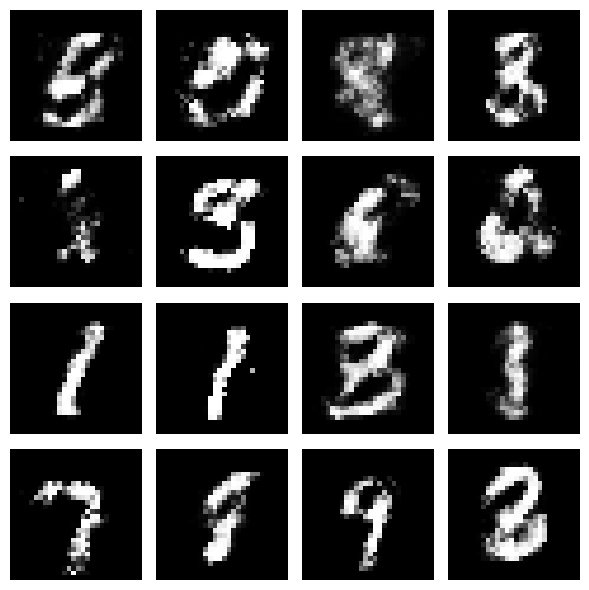

Epoch [31/100] | D_loss: 0.9031 | G_loss: 1.7174
Epoch [32/100] | D_loss: 0.8953 | G_loss: 1.7827
Epoch [33/100] | D_loss: 0.9209 | G_loss: 1.7592
Epoch [34/100] | D_loss: 0.9235 | G_loss: 1.6328
Epoch [35/100] | D_loss: 0.9215 | G_loss: 1.5997
Epoch [36/100] | D_loss: 0.9076 | G_loss: 1.6085
Epoch [37/100] | D_loss: 0.8856 | G_loss: 1.7371
Epoch [38/100] | D_loss: 0.9005 | G_loss: 1.6779
Epoch [39/100] | D_loss: 0.8899 | G_loss: 1.6957
Epoch [40/100] | D_loss: 0.8815 | G_loss: 1.7354


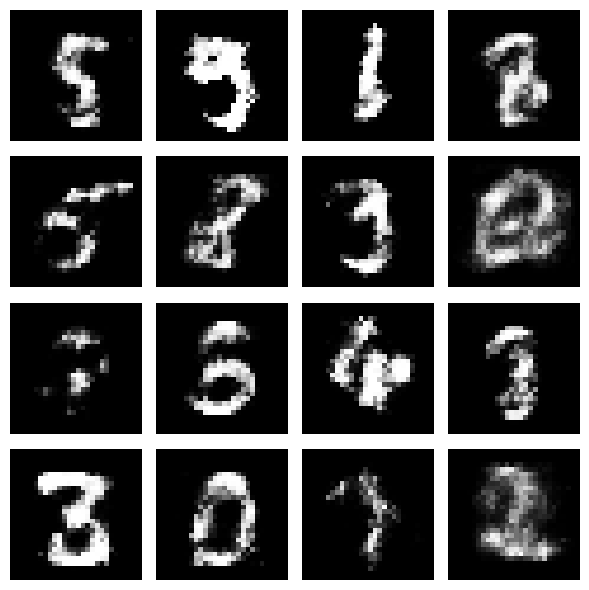

Epoch [41/100] | D_loss: 0.8842 | G_loss: 1.7431
Epoch [42/100] | D_loss: 0.8826 | G_loss: 1.6904
Epoch [43/100] | D_loss: 0.8741 | G_loss: 1.7032
Epoch [44/100] | D_loss: 0.8750 | G_loss: 1.7380
Epoch [45/100] | D_loss: 0.8700 | G_loss: 1.7429
Epoch [46/100] | D_loss: 0.8748 | G_loss: 1.7273
Epoch [47/100] | D_loss: 0.8647 | G_loss: 1.7509
Epoch [48/100] | D_loss: 0.8719 | G_loss: 1.7420
Epoch [49/100] | D_loss: 0.8578 | G_loss: 1.7443
Epoch [50/100] | D_loss: 0.8444 | G_loss: 1.7961


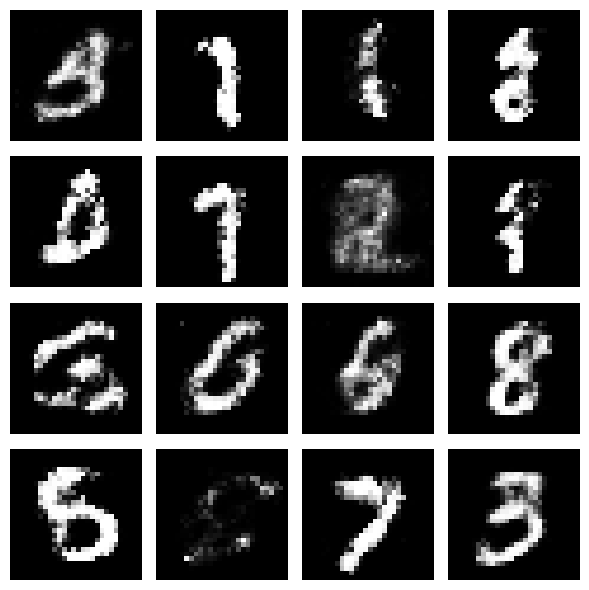

Epoch [51/100] | D_loss: 0.8514 | G_loss: 1.7708
Epoch [52/100] | D_loss: 0.8400 | G_loss: 1.7839
Epoch [53/100] | D_loss: 0.8383 | G_loss: 1.8172
Epoch [54/100] | D_loss: 0.8312 | G_loss: 1.8257
Epoch [55/100] | D_loss: 0.8315 | G_loss: 1.8226
Epoch [56/100] | D_loss: 0.8238 | G_loss: 1.8259
Epoch [57/100] | D_loss: 0.8144 | G_loss: 1.8536
Epoch [58/100] | D_loss: 0.8156 | G_loss: 1.8314
Epoch [59/100] | D_loss: 0.8142 | G_loss: 1.8513
Epoch [60/100] | D_loss: 0.8081 | G_loss: 1.8573


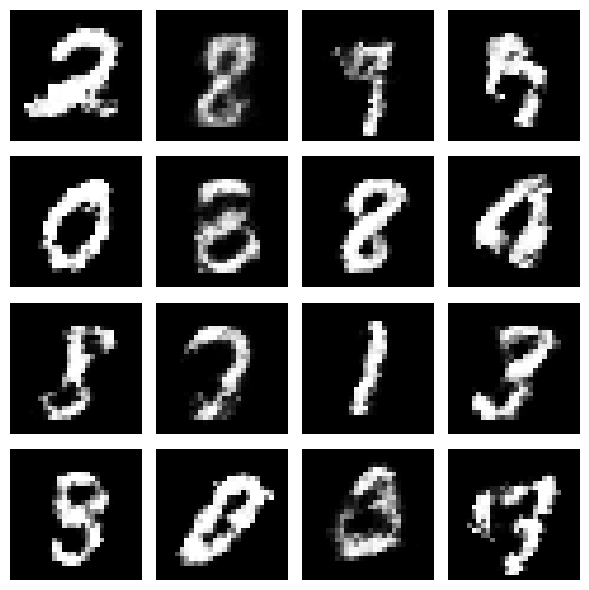

Epoch [61/100] | D_loss: 0.8093 | G_loss: 1.8462
Epoch [62/100] | D_loss: 0.8064 | G_loss: 1.8496
Epoch [63/100] | D_loss: 0.8056 | G_loss: 1.8328
Epoch [64/100] | D_loss: 0.8096 | G_loss: 1.8367
Epoch [65/100] | D_loss: 0.7945 | G_loss: 1.8373
Epoch [66/100] | D_loss: 0.7975 | G_loss: 1.8526
Epoch [67/100] | D_loss: 0.7923 | G_loss: 1.8363
Epoch [68/100] | D_loss: 0.7973 | G_loss: 1.8480
Epoch [69/100] | D_loss: 0.7952 | G_loss: 1.8445
Epoch [70/100] | D_loss: 0.7936 | G_loss: 1.8521


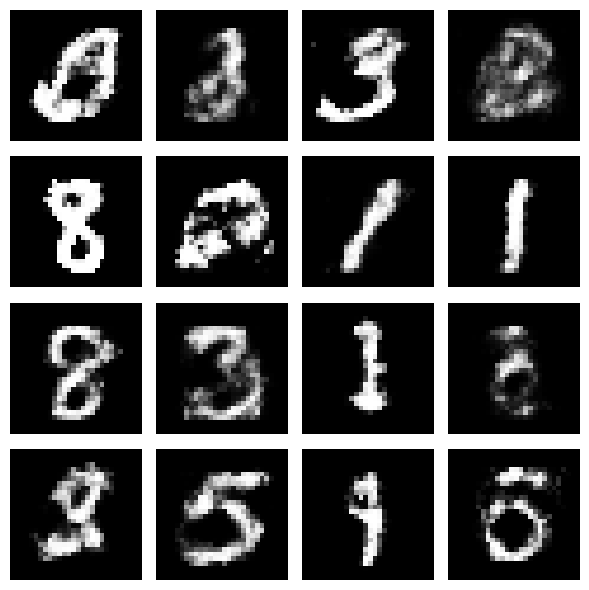

Epoch [71/100] | D_loss: 0.7917 | G_loss: 1.8535
Epoch [72/100] | D_loss: 0.7908 | G_loss: 1.8450
Epoch [73/100] | D_loss: 0.7934 | G_loss: 1.8350
Epoch [74/100] | D_loss: 0.7887 | G_loss: 1.8365
Epoch [75/100] | D_loss: 0.7840 | G_loss: 1.8401
Epoch [76/100] | D_loss: 0.7854 | G_loss: 1.8380
Epoch [77/100] | D_loss: 0.7750 | G_loss: 1.8420
Epoch [78/100] | D_loss: 0.7806 | G_loss: 1.8404
Epoch [79/100] | D_loss: 0.7783 | G_loss: 1.8379
Epoch [80/100] | D_loss: 0.7737 | G_loss: 1.8363


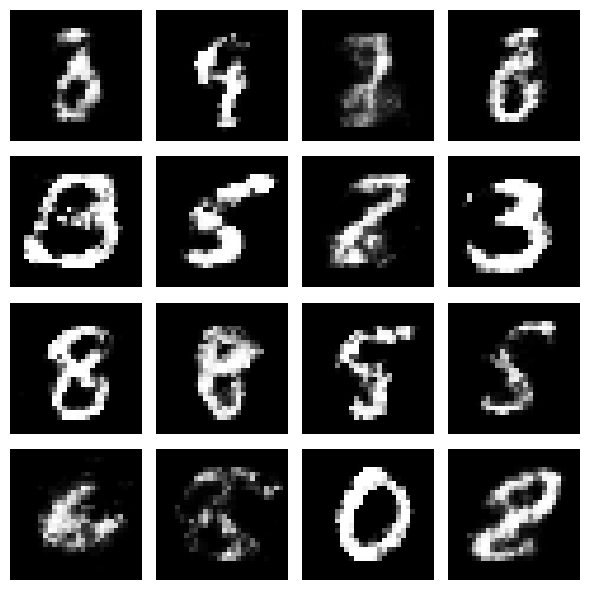

Epoch [81/100] | D_loss: 0.7643 | G_loss: 1.8302
Epoch [82/100] | D_loss: 0.7745 | G_loss: 1.8360
Epoch [83/100] | D_loss: 0.7633 | G_loss: 1.8304
Epoch [84/100] | D_loss: 0.7642 | G_loss: 1.8494
Epoch [85/100] | D_loss: 0.7601 | G_loss: 1.8588
Epoch [86/100] | D_loss: 0.7567 | G_loss: 1.8568
Epoch [87/100] | D_loss: 0.7543 | G_loss: 1.8563
Epoch [88/100] | D_loss: 0.7487 | G_loss: 1.8685
Epoch [89/100] | D_loss: 0.7467 | G_loss: 1.8532
Epoch [90/100] | D_loss: 0.7414 | G_loss: 1.8716


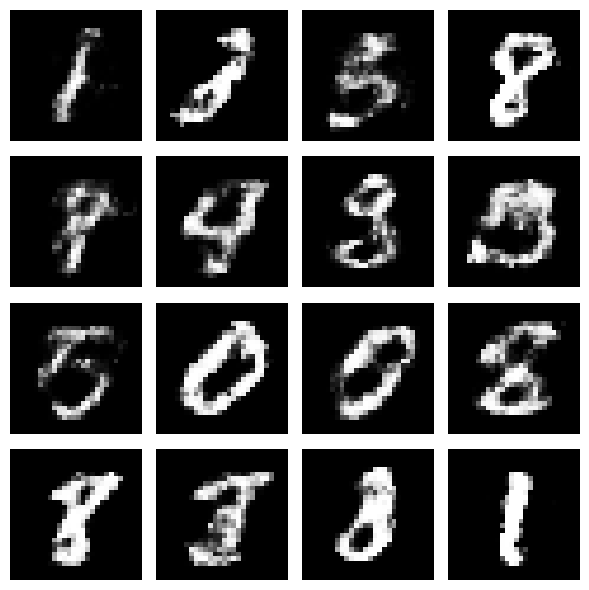

Epoch [91/100] | D_loss: 0.7404 | G_loss: 1.8713
Epoch [92/100] | D_loss: 0.7352 | G_loss: 1.8736
Epoch [93/100] | D_loss: 0.7410 | G_loss: 1.8742
Epoch [94/100] | D_loss: 0.7350 | G_loss: 1.8840
Epoch [95/100] | D_loss: 0.7272 | G_loss: 1.8891
Epoch [96/100] | D_loss: 0.7310 | G_loss: 1.8948
Epoch [97/100] | D_loss: 0.7282 | G_loss: 1.9013
Epoch [98/100] | D_loss: 0.7213 | G_loss: 1.9157
Epoch [99/100] | D_loss: 0.7243 | G_loss: 1.9048
Epoch [100/100] | D_loss: 0.7201 | G_loss: 1.9115


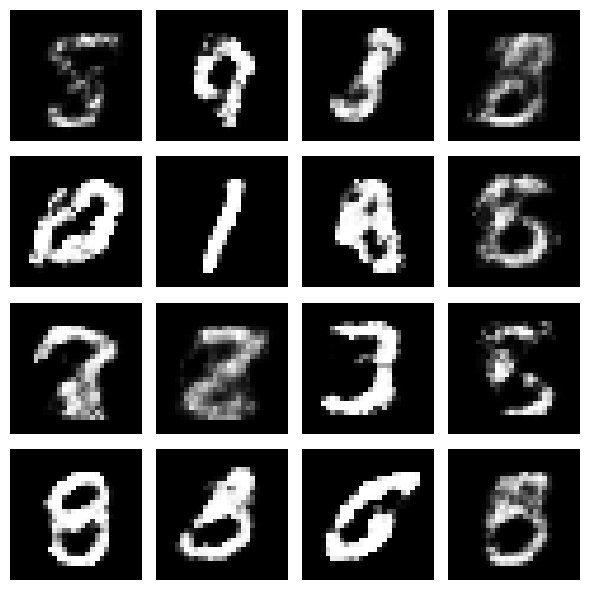

In [13]:
# Main training loop with epoch-level logging

for epoch in range(config["epochs"]):
    # Store batch losses for this epoch
    d_loss_list = []
    g_loss_list = []
    d_real_loss_list = []
    d_fake_loss_list = []

    for batch_idx, (real_images, _) in enumerate(train_loader):
        # Flatten images from [batch, 1, 28, 28] to [batch, 784]
        real_images = real_images.view(-1, config["image_dim"]).to(device)
        batch_size = real_images.size(0)

        # Create real and fake labels
        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # =========================================================
        # 1) Train the Discriminator
        # =========================================================
        # Sample random noise
        z = torch.randn(batch_size, config["latent_dim"], device=device)

        # Generate fake images
        fake_images = G(z)

        # Discriminator predictions
        d_real = D(real_images)
        d_fake = D(fake_images.detach())

        # Discriminator loss
        d_real_loss = criterion(d_real, real_labels)
        d_fake_loss = criterion(d_fake, fake_labels)
        d_loss = d_real_loss + d_fake_loss

        # Update Discriminator
        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # =========================================================
        # 2) Train the Generator
        # =========================================================
        # Sample new noise
        z = torch.randn(batch_size, config["latent_dim"], device=device)

        # Generate fake images again
        fake_images = G(z)

        # Generator tries to fool the Discriminator
        d_fake_for_g = D(fake_images)
        g_loss = criterion(d_fake_for_g, real_labels)

        # Update Generator
        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        # Store losses for epoch-level averaging
        d_loss_list.append(d_loss.item())
        g_loss_list.append(g_loss.item())
        d_real_loss_list.append(d_real_loss.item())
        d_fake_loss_list.append(d_fake_loss.item())

    # Compute average losses for the epoch
    avg_d_loss = np.mean(d_loss_list)
    avg_g_loss = np.mean(g_loss_list)
    avg_d_real_loss = np.mean(d_real_loss_list)
    avg_d_fake_loss = np.mean(d_fake_loss_list)

    # Print a clean epoch summary
    print(
        f"Epoch [{epoch + 1}/{config['epochs']}] | "
        f"D_loss: {avg_d_loss:.4f} | "
        f"G_loss: {avg_g_loss:.4f}"
    )

    # Log scalar metrics to W&B once per epoch
    wandb.log({
        "epoch": epoch + 1,
        "D_loss": avg_d_loss,
        "G_loss": avg_g_loss,
        "D_real_loss": avg_d_real_loss,
        "D_fake_loss": avg_d_fake_loss
    }, step=epoch + 1)

    # Log images to W&B every epoch if requested
    if (epoch + 1) % config["wandb_image_interval"] == 0:
        fig = make_generated_figure(G, config["latent_dim"], num_images=16)

        wandb.log({
            "generated_samples": wandb.Image(fig, caption=f"Epoch {epoch + 1}")
        }, step=epoch + 1)

        # Show images in Jupyter only every few epochs
        if (epoch + 1) % config["jupyter_plot_interval"] == 0:
            plt.show()

        plt.close(fig)

## Display final generated samples

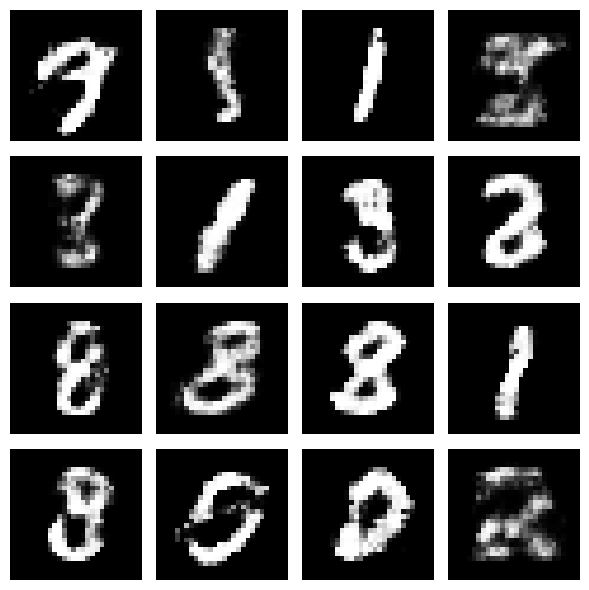

In [14]:
# Show final generated images after training
show_generated_images(G, config["latent_dim"], num_images=16)

## Save final generated samples locally

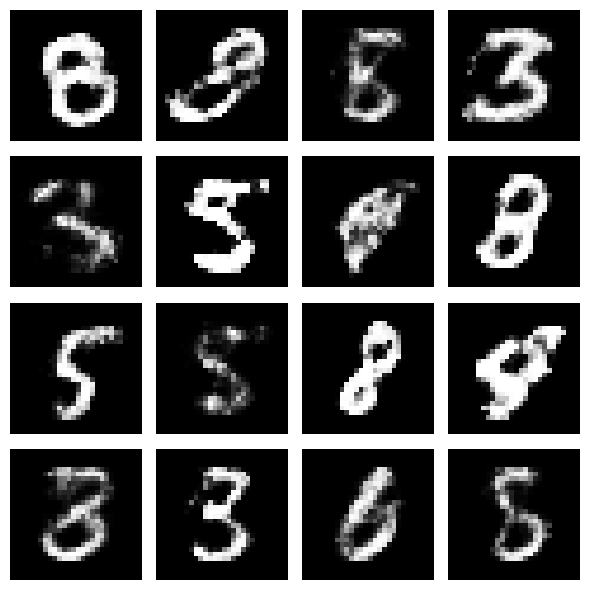

Saved final generated samples to: C:\Users\hamsab\OneDrive - Luleå University of Technology\JupyterFolder\github\D7047E\Lab2\src\out\task1_final_samples.png


In [15]:
# Save final generated images to disk
G.eval()

with torch.no_grad():
    z = torch.randn(16, config["latent_dim"], device=device)
    final_images = G(z).view(-1, 28, 28).cpu().numpy()

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(final_images[i], cmap="gray")
    ax.axis("off")

plt.tight_layout()
save_path = OUT_DIR / "task1_final_samples.png"
plt.savefig(save_path, bbox_inches="tight")
plt.show()
plt.close()

print(f"Saved final generated samples to: {save_path}")

## Finish the W&B run

In [16]:
wandb.finish()

D_fake_loss,▁▅▅▅▆▇▇█████▇██▇▇▇▇▇▆▆▆▆▆▆▆▅▆▅▅▅▅▅▅▅▅▅▅▅
D_loss,▁▁▁▂▄████████████▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▆▆▆▆▆▆
D_real_loss,▁▂▅▇█████▇██▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▆▇▆▆▆▆▆
G_loss,█▆▆▅▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▂▂▂▂▁▁▁▁▂▂▂▂▂
epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▇▇▇▇▇▇████
D_fake_loss,0.31831
D_loss,0.72006
D_real_loss,0.40174
G_loss,1.91154
epoch,100
